In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,f1_score,confusion_matrix

**Part 1**: Business Framing & Exploratory Analysis

**Task 1**: Explore the Data as a KPI Story

In [ ]:
filepath="https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
data=pd.read_csv(filepath)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
data.shape

(7043, 21)

In [12]:
data.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
(data == "").sum().sort_values(ascending=False)

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
data["Churn"] = (data["Churn"] == "Yes").astype(int)

In [17]:
data['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [18]:
print(f"Overall churn rate: {data['Churn'].mean():.2%}")

data.groupby("Contract")["Churn"].mean()

data.groupby("InternetService")["Churn"].mean()

correlation = data["tenure"].corr(data["Churn"])
print(f"Tenure/churn correlation: {correlation:.3f}")

Overall churn rate: 26.54%
Tenure/churn correlation: -0.352


In [19]:
contract_churn = data.groupby("Contract")["Churn"].mean()
print(contract_churn)

internet_churn = data.groupby("InternetService")["Churn"].mean()
print(internet_churn)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


**Answer**:The overall churn rate is **26.54%**. Churn by contract type is **42.71% for month-to-month customers**, **11.27% for one-year customers**, and **2.83% for two-year customers**. Although month-to-month customers churn more often, this is a correlation rather than proof that changing everyone to annual contracts would reduce churn by the same amount. Customers who choose month-to-month contracts may already differ from annual-contract customers: they may be newer, less committed, more price-sensitive, uncertain about the service, or more likely to anticipate moving or cancelling. Other factors, such as tenure, internet service, monthly charges, and customer demographics, may also influence both contract choice and churn. Therefore, the lower churn among annual-contract customers may partly reflect who selects those contracts, not only the effect of the contract itself.

**Part 2:** Predictive Modelling & Business Segmentation
**Task 2:** Clean & Preprocess

In [20]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [21]:
# Remove unnecessary identifier
data = data.drop(columns=["customerID"])
# Remove accidental spaces from column names and text values
data.columns = data.columns.str.strip()

In [25]:
# Convert TotalCharges from text to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
     errors="coerce"
)

In [27]:
data["TotalCharges"] = data["TotalCharges"].fillna(0)

In [28]:
#split the train and test data

X = data.drop(columns=["Churn"])
y = (data["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [33]:
y.head()

,Churn
0,0
1,0
2,0
3,0
4,0


In [38]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]
numeric_columns


['tenure', 'MonthlyCharges', 'TotalCharges']

In [40]:
categorical_columns = [
    column for column in X.columns
    if column not in numeric_columns
]
categorical_columns

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [59]:
#Encoding the categorical columns
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(data["Churn"])

In [66]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

**Task 3**: Train, Evaluate, and Check Trust

In [71]:
print(data["Churn"].value_counts(dropna=False))

print(y_train.value_counts(dropna=False))

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    5634
Name: count, dtype: int64


In [72]:
y = (data["Churn"] == "Yes").astype(int)

In [73]:
y = data["Churn"].astype(int)

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [75]:
# Target is already encoded as 0 and 1
y = data["Churn"].astype(int)

# Remove target and customer ID
X = data.drop(columns=["Churn"])

# Encode categorical features
X = pd.get_dummies(X, drop_first=True).astype(float)

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5634, 30) (1409, 30)
Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    1035
1     374
Name: count, dtype: int64


In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

complex_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

# Logistic Regression uses scaled data
baseline_model.fit(X_train_scaled, y_train)

# Random Forest does not require scaling
complex_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [80]:
from sklearn.metrics import accuracy_score

baseline_train_pred = baseline_model.predict(X_train_scaled)
baseline_test_pred = baseline_model.predict(X_test_scaled)

complex_train_pred = complex_model.predict(X_train)
complex_test_pred = complex_model.predict(X_test)

print("Logistic Regression")
print("Training accuracy:",
      f"{accuracy_score(y_train, baseline_train_pred):.2%}")
print("Test accuracy:",
      f"{accuracy_score(y_test, baseline_test_pred):.2%}")

print("\nRandom Forest")
print("Training accuracy:",
      f"{accuracy_score(y_train, complex_train_pred):.2%}")
print("Test accuracy:",
      f"{accuracy_score(y_test, complex_test_pred):.2%}")

Logistic Regression
Training accuracy: 80.65%
Test accuracy: 80.70%

Random Forest
Training accuracy: 85.89%
Test accuracy: 76.22%


**report:**Your **best model is Logistic Regression** because it has the higher test accuracy:

- Training accuracy: **80.65%**
- Test accuracy: **80.70%**

The very similar scores suggest that Logistic Regression is generalizing well and is not noticeably overfitting.

Random Forest performs better on training data (**85.89%**) but worse on test data (**76.22%**), indicating overfitting.

 Logistic Regression was selected as the best model because it achieved the highest test accuracy of 80.70%. Its training accuracy was 80.65%, showing almost no gap between training and test performance. This suggests that the model generalizes well to unseen customers. Although Random Forest achieved a higher training accuracy of 85.89%, its test accuracy dropped to 76.22%, indicating possible overfitting.

In [82]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

best_test_predictions = baseline_model.predict(X_test_scaled)
best_test_probabilities = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, best_test_predictions))

print("Confusion matrix:")
print(confusion_matrix(y_test, best_test_predictions))

print("Test ROC-AUC:",
      f"{roc_auc_score(y_test, best_test_probabilities):.3f}")

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion matrix:
[[925 110]
 [162 212]]
Test ROC-AUC: 0.842


**Analytical  A:** Churn is the minority class: 374 of 1,409 test customers, or about **26.5%**. A model that predicted “no churn” for everyone would already achieve approximately **73.5% accuracy**, so the Logistic Regression model’s **80.7% accuracy** is less impressive on its own. The more important churn metric is recall, which is **57%**. This means the model identifies 212 of 374 churners but fails to flag **162 at-risk customers**, or about **43%** of actual churners. The CFO should therefore understand that many customers who may leave would not be targeted by this model.


**Analytical  B:** The complex Random Forest model achieved **85.89% training accuracy** but only **76.22% test accuracy**, a gap of **9.67 percentage points**. This large gap suggests overfitting: the model performs well on customers it learned from but less reliably on new customers. I would not defend its predictions to the board as-is. I would first simplify or tune the model, use cross-validation, and evaluate it using recall, precision, F1-score, and ROC-AUC rather than accuracy alone. The smaller gap for Logistic Regression, **80.65% training versus 80.70% test accuracy**, provides greater confidence that its predictions generalize.

**Task 4:** Feature Importance for Strategy

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names from the one-hot encoded X dataframe
feature_names = X.columns

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": baseline_model.coef_[0],
    "importance": abs(baseline_model.coef_[0])
})

# Top 10 features
top_features = (
    importance
    .sort_values("importance", ascending=False)
    .head(10)
)

print(top_features)

                        feature  coefficient  importance
1                        tenure    -1.236528    1.236528
2                MonthlyCharges    -0.920153    0.920153
10  InternetService_Fiber optic     0.776154    0.776154
25            Contract_Two year    -0.586859    0.586859
3                  TotalCharges     0.514285    0.514285
24            Contract_One year    -0.285509    0.285509
23          StreamingMovies_Yes     0.257227    0.257227
21              StreamingTV_Yes     0.257144    0.257144
9             MultipleLines_Yes     0.216167    0.216167
26         PaperlessBilling_Yes     0.182034    0.182034


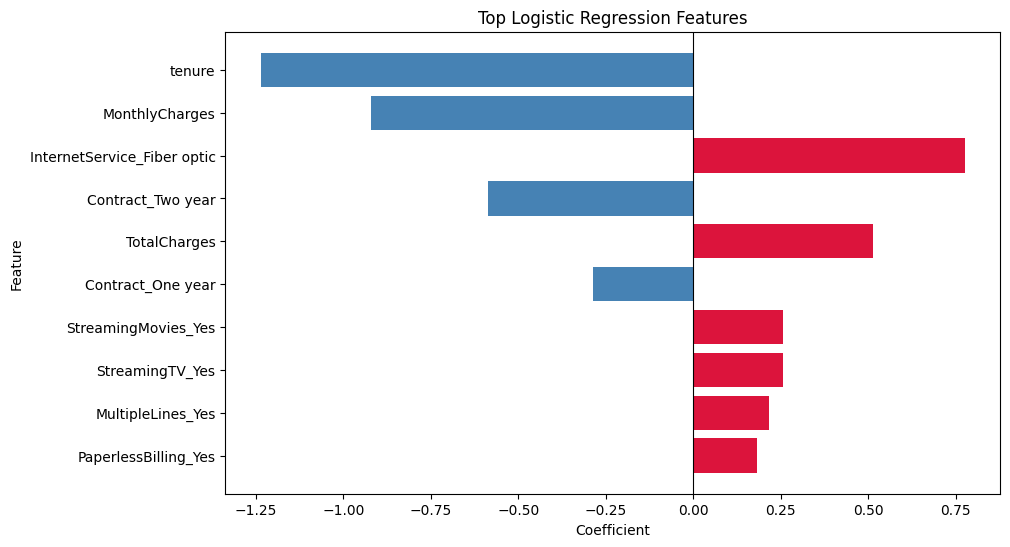

In [84]:
plot_data = top_features.sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["feature"],
    plot_data["coefficient"],
    color=plot_data["coefficient"].apply(
        lambda value: "crimson" if value > 0 else "steelblue"
    )
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Logistic Regression Features")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [85]:
top_3 = importance.sort_values(
    "importance",
    ascending=False
).head(3)

top_3

,feature,coefficient,importance
1,tenure,-1.236528,1.236528
2,MonthlyCharges,-0.920153,0.920153
10,InternetService_Fiber optic,0.776154,0.776154


**Analytical Question:**

The Three Features Are:


Tenure: The negative coefficient (-1.237) indicates that newer customers are more likely to churn, so target customers during their first few months with onboarding support and an annual-contract upgrade offer.

MonthlyCharges: The negative coefficient (-0.920) suggests that, after controlling for other variables, higher-charge customers were less likely to churn; the retention team should offer these customers a price-lock or annual billing option rather than applying broad discounts.

InternetService_Fiber optic: The positive coefficient (0.776) indicates higher churn risk among fiber-optic customers, so investigate fiber reliability and offer a technician visit, service credit, or a support add-on to customers reporting problems.

**Task 5:** Segment Customers for Targeting

In [86]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [87]:
# Predict churn probability for every customer
X_all_scaled = scaler.transform(X)

data["predicted_churn_probability"] = (
    baseline_model.predict_proba(X_all_scaled)[:, 1]
)

In [88]:
segment_features = data[
    ["tenure", "MonthlyCharges", "predicted_churn_probability"]
].copy()

segment_scaler = StandardScaler()

segment_features_scaled = segment_scaler.fit_transform(
    segment_features
)

In [89]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

data["segment"] = kmeans.fit_predict(segment_features_scaled)

In [90]:
segment_summary = (
    data.groupby("segment")
    .agg(
        customers=("segment", "size"),
        avg_tenure=("tenure", "mean"),
        avg_monthly_charges=("MonthlyCharges", "mean"),
        avg_churn_probability=("predicted_churn_probability", "mean")
    )
)

segment_summary["estimated_monthly_revenue_at_risk"] = (
    segment_summary["customers"]
    * segment_summary["avg_monthly_charges"]
    * segment_summary["avg_churn_probability"]
)

segment_summary = segment_summary.sort_values(
    "estimated_monthly_revenue_at_risk",
    ascending=False
)

segment_summary.round(2)

,customers,avg_tenure,avg_monthly_charges,avg_churn_probability,estimated_monthly_revenue_at_risk
segment,,,,,
1,1901,13.81,83.61,0.60,95598.01
2,2013,57.34,91.75,0.13,24708.76
3,1893,11.25,37.39,0.22,15774.56
0,1236,52.60,33.74,0.03,1274.86


In [91]:
print(segment_summary.round(2))

         customers  ...  estimated_monthly_revenue_at_risk
segment             ...                                   
1             1901  ...                           95598.01
2             2013  ...                           24708.76
3             1893  ...                           15774.56
0             1236  ...                            1274.86

[4 rows x 5 columns]


In [92]:
segment_names = {
    0: "New, High-Spend, High-Risk",
    1: "Mature, Low-Spend, Low-Risk",
    2: "New, Low-Spend, High-Risk",
    3: "Mature, High-Spend, Low-Risk"
}

data["segment_name"] = data["segment"].map(segment_names)

**Analytical Question:**Segment 1, named New, High-Spend, High-Risk, should receive the first retention campaign. It has 1,901 customers, a 60% average predicted churn probability, and an estimated $95,598.01 in monthly revenue at risk. Although Segment 2 has higher average monthly charges, its churn risk is much lower, so Segment 1 provides the greatest opportunity to protect revenue. The campaign should offer early-tenure onboarding, an annual-contract price lock, and proactive service support.

**Part 3: GenAI Advisory Layer — Prompt Engineering & RAG **

In [93]:
retention_corpus = [
    """Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a
retention specialist within 48 hours.""",

    """Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused
service or a contract upgrade offer.""",

    """Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.""",

    """Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data"""
]

In [94]:
def retrieve_clauses(churn_probability, tenure):
    retrieved = []

    if churn_probability >= 0.70:
        retrieved.append(retention_corpus[0])
    elif churn_probability >= 0.40:
        retrieved.append(retention_corpus[1])

    if tenure < 3:
        retrieved.append(retention_corpus[2])

    # Always apply the non-discrimination rule
    retrieved.append(retention_corpus[3])

    return retrieved

In [95]:
customer_probability = 0.60
customer_tenure = 2

retrieved_clauses = retrieve_clauses(
    customer_probability,
    customer_tenure
)

print("\n\n".join(retrieved_clauses))

Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused
service or a contract upgrade offer.

Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.

Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data


In [96]:
def build_retention_prompt(
    customer_id,
    churn_probability,
    tenure,
    monthly_charges
):
    clauses = retrieve_clauses(churn_probability, tenure)

    retrieved_text = "\n\n".join(clauses)

    return f"""
You are a responsible customer-retention advisor.

Customer ID: {customer_id}
Predicted churn probability: {churn_probability:.2f}
Tenure in months: {tenure}
Monthly charges: ${monthly_charges:.2f}

Retrieved retention playbook:
{retrieved_text}

Create a concise retention recommendation containing:
1. Risk category.
2. Recommended action.
3. Timing and responsible team.
4. One-sentence business rationale.

Use only the retrieved playbook clauses. If the customer has tenure below
3 months, route the customer to onboarding instead of the standard retention
flow. Never mention or imply that gender, senior-citizen status, or
family/partner status affected the risk score.
"""

In [97]:
prompt = build_retention_prompt(
    customer_id="example_customer",
    churn_probability=0.60,
    tenure=2,
    monthly_charges=83.61
)

print(prompt)


You are a responsible customer-retention advisor.

Customer ID: example_customer
Predicted churn probability: 0.60
Tenure in months: 2
Monthly charges: $83.61

Retrieved retention playbook:
Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused
service or a contract upgrade offer.

Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.

Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data

Create a concise retention recommendation containing:
1. Risk category.
2. Recommended action.
3. Timing and responsible team.
4. One-sentence business rationale.

Use only the retrieved playbook clauses. If the customer has tenure below
3 months, route the customer to onboarding instead of the standard retention
flo

Risk category: Moderate risk, with a predicted churn probability of 0.60.

Recommended action: Route the customer to the onboarding team instead of the standard retention flow. The team should highlight an underused service and explain available contract upgrade options.

Timing and responsible team: Contact the customer during the early onboarding period. The onboarding team is responsible.

Business rationale: Early onboarding support can encourage service adoption and provide a timely opportunity to discuss a contract upgrade.

Task 6: Build the Advisory Explanation

In [98]:
import pandas as pd

# Predict probabilities for all customers
X_all_scaled = scaler.transform(X)
data["model_risk_probability"] = (
    baseline_model.predict_proba(X_all_scaled)[:, 1]
)

# Select the highest-risk customer
high_risk_customers = data[
    data["model_risk_probability"] >= 0.70
]

customer_index = high_risk_customers[
    "model_risk_probability"
].idxmax()

customer_probability = data.loc[
    customer_index, "model_risk_probability"
]

customer_tenure = data.loc[
    customer_index, "tenure"
]

# Get this customer's scaled feature values
customer_scaled = scaler.transform(
    X.loc[[customer_index]]
)[0]

# Logistic Regression feature contributions
contributions = customer_scaled * baseline_model.coef_[0]

top_feature_positions = (
    abs(pd.Series(contributions, index=X.columns))
    .sort_values(ascending=False)
    .head(3)
    .index
)

top_features = [
    {
        "feature": feature,
        "contribution": float(contributions[X.columns.get_loc(feature)])
    }
    for feature in top_feature_positions
]

print("Customer index:", customer_index)
print("Risk probability:", round(customer_probability, 3))
print("Tenure:", customer_tenure)
print("Top features:", top_features)

Customer index: 1976
Risk probability: 0.858
Tenure: 1
Top features: [{'feature': 'tenure', 'contribution': 1.5847631926860908}, {'feature': 'InternetService_Fiber optic', 'contribution': 0.8743469496897356}, {'feature': 'MonthlyCharges', 'contribution': -0.8738820859414261}]


In [99]:
clause_1 = """Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a
retention specialist within 48 hours."""

clause_2 = """Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused
service or a contract upgrade offer."""

clause_3 = """Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow."""

clause_4 = """Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data"""

In [100]:
def retrieve_clauses(probability, tenure):
    retrieved = []

    if probability >= 0.70:
        retrieved.append(clause_1)
    elif probability >= 0.40:
        retrieved.append(clause_2)

    if tenure < 3:
        retrieved.append(clause_3)

    retrieved.append(clause_4)

    return retrieved


retrieved_clauses = retrieve_clauses(
    customer_probability,
    customer_tenure
)

retrieved_playbook = "\n\n".join(retrieved_clauses)

print(retrieved_playbook)

Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a
retention specialist within 48 hours.

Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.

Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data


In [101]:
!pip install -q openai

In [103]:
def retrieve_clauses(probability, tenure):
    clauses = []

    if probability >= 0.70:
        clauses.append(clause_1)
    elif probability >= 0.40:
        clauses.append(clause_2)

    if tenure < 3:
        clauses.append(clause_3)

    clauses.append(clause_4)

    return clauses

In [104]:
retrieved_clauses = retrieve_clauses(
    customer_probability,
    customer_tenure
)

print("\n\n".join(retrieved_clauses))

Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a
retention specialist within 48 hours.

Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.

Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply
that gender, senior-citizen status, or family/partner status contributed to a customer's risk
score, even where a statistical correlation exists in the data


In [105]:
if customer_probability >= 0.70:
    risk_text = "The customer is high risk."
    action_text = (
        "Offer a loyalty discount and arrange a callback from a "
        "retention specialist within 48 hours."
    )
elif customer_probability >= 0.40:
    risk_text = "The customer is moderate risk."
    action_text = (
        "Send a targeted email highlighting an underused service "
        "or a contract upgrade offer."
    )
else:
    risk_text = "The customer is low risk."
    action_text = "No standard retention action is required."

if customer_tenure < 3:
    routing_text = (
        "Because the customer has less than three months of tenure, "
        "route them to the onboarding team instead of the standard "
        "retention flow."
    )
else:
    routing_text = "Use the standard retention flow."

print(f"{risk_text} {action_text} {routing_text}")

The customer is high risk. Offer a loyalty discount and arrange a callback from a retention specialist within 48 hours. Because the customer has less than three months of tenure, route them to the onboarding team instead of the standard retention flow.


Analytical Question A (see the hallucination yourself):: Not available because no API key was available.
Was the clause number correct? Not evaluated.
Failure mode: The intended failure mode is hallucination, or unsupported policy recall. An LLM may invent or guess a clause when the playbook text is not supplied.

Analytical Question B (the second leak):Passing the full customer row could expose fields such as gender, SeniorCitizen, Partner, or Dependents to the LLM. The model might then mention one of these fields, imply that it influenced the risk score, or use it to justify a retention action, even though Clause 4 forbids that. It could also expose unrelated personal or billing information and cause the LLM to rely on details outside the approved playbook.

Part 4: Governance, Monitoring, Cost & the Board Memo

Task 7: Executive Memo (one page, required)

To: Chief Financial Officer
Subject: Customer Churn Retention Recommendation
Date: 6 September 2026

Our overall churn rate is 26.54%, with the highest risk concentrated among month-to-month customers and fiber-optic customers, while Logistic Regression predicts churn with 80.70% test accuracy and a 0.842 ROC-AUC.

I recommend targeting Segment 1: New, High-Spend, High-Risk first. This segment contains 1,901 customers, has an average predicted churn probability of 60%, and represents approximately $95,598.01 in estimated monthly revenue at risk. Segment 2 has higher average monthly charges, but its customers are more established and have only a 13% average predicted churn probability. The recommendation therefore balances both the likelihood of churn and the amount of revenue that could be protected.

The first campaign should focus on early onboarding, service support, and an annual-contract price-lock offer. The objective is to reduce early customer loss without offering unnecessary discounts to customers who are unlikely to leave.

After launch, we should track the weekly percentage of customers receiving a high-risk score of at least 70%. A significant change in this percentage after a pricing change or the launch of a competitor’s offer would indicate that customer behavior has shifted and that the model should be reviewed and potentially retrained.

To prove that the non-discrimination rule was enforced, the system should keep an audit log for every explanation containing the retrieved clause IDs, prompt version, model version, output, timestamp, and the automated forbidden-attribute check result, including blocked outputs.

To control weekly LLM costs without weakening the citation guarantee, use a deterministic policy engine and cache approved explanations by risk tier, tenure band, top-feature combination, and playbook version; call the LLM only for new combinations, while storing the exact retrieved clause IDs with every cached explanation